## Importing libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
from skfuzzy import control as ctrl
import skfuzzy as fuzz

In [16]:

# Simulated passenger boarding/alighting data
time_steps = 200
np.random.seed(42)  # For reproducibility
boarding_data = np.random.randint(0, 20, time_steps)
alighting_data = np.random.randint(0, 20, time_steps)

In [19]:
# Preparing the data for Hidden Markov Model for passenger behavior
X = np.column_stack([boarding_data, alighting_data])
n_components = 2  # Provides number of hidden states
hmm_model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=1000)
hmm_model.fit(X)
states = hmm_model.predict(X)

In [ ]:
# Fuzzy Logic System for decision making
boarding = ctrl.Antecedent(np.arange(0, 11, 1), 'boarding')
alighting = ctrl.Antecedent(np.arange(0, 11, 1), 'alighting')
crowd_level = ctrl.Consequent(np.arange(0, 101, 1), 'crowd_level')

boarding.automf(3)
alighting.automf(3)
crowd_level['low'] = fuzz.trimf(crowd_level.universe, [0, 25, 50])
crowd_level['medium'] = fuzz.trimf(crowd_level.universe, [25, 50, 75])
crowd_level['high'] = fuzz.trimf(crowd_level.universe, [50, 100, 100])

rule1 = ctrl.Rule(boarding['poor'] | alighting['poor'], crowd_level['low'])
rule2 = ctrl.Rule(boarding['average'] | alighting['average'], crowd_level['medium'])
rule3 = ctrl.Rule(boarding['good'] | alighting['good'], crowd_level['high'])

crowd_control = ctrl.ControlSystem([rule1, rule2, rule3])
crowd_simulation = ctrl.ControlSystemSimulation(crowd_control)

predicted_crowd_levels = []
for i in range(time_steps):
    crowd_simulation.input['boarding'] = boarding_data[i]
    crowd_simulation.input['alighting'] = alighting_data[i]
    crowd_simulation.compute()
    predicted_crowd_levels.append(crowd_simulation.output['crowd_level'])

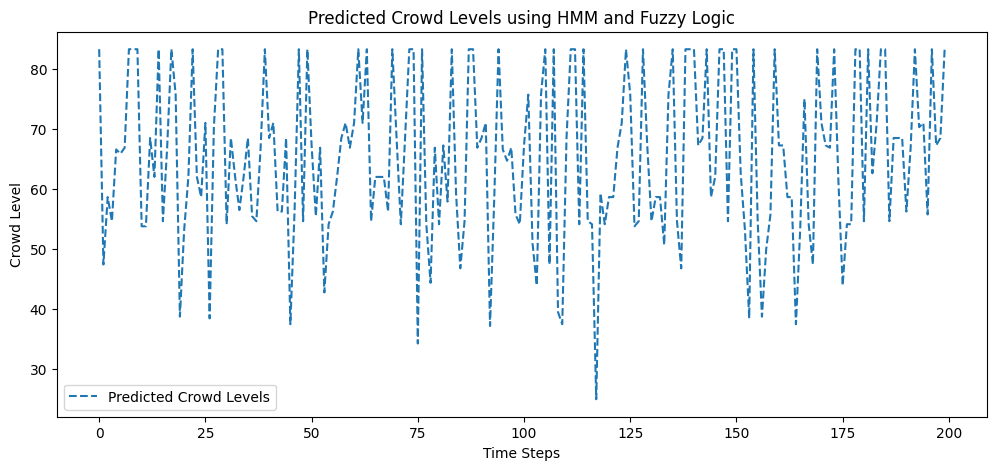

In [ ]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(predicted_crowd_levels, label='Predicted Crowd Levels', linestyle='dashed')
plt.xlabel("Time Steps")
plt.ylabel("Crowd Level")
plt.title("Predicted Crowd Levels using HMM and Fuzzy Logic")
plt.legend()
plt.show()



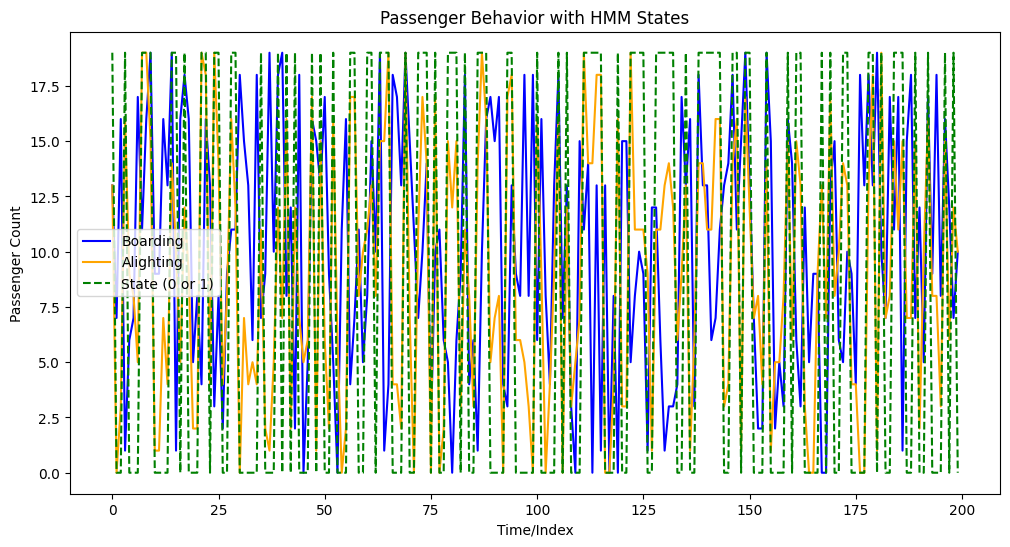

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(boarding_data, label="Boarding", color="blue")
plt.plot(alighting_data, label="Alighting", color="orange")
plt.plot(states * max(boarding_data), label="State (0 or 1)", color="green", linestyle="--")
plt.xlabel("Time/Index")
plt.ylabel("Passenger Count")
plt.legend()
plt.title("Passenger Behavior with HMM States")
plt.show()

## Model evaluation

In [22]:
# Evaluates the log_likelihood
log_likelihood = hmm_model.score(X)
print(f"Log-likelihood of the model: {log_likelihood:.2f}")

Log-likelihood of the model: -1253.97
